# PROGETTO DI CALCOLO SCIENTIFICO: EQUAZIONE DI ADVEZIONE-DIFFUSIONE
Lo script simula la dinamica di dispersione di un inquinante lungo il tratto di un fiume, risolvendo numericamente l'equazione di advezione-diffusione tramite la semidiscretizzazione spaziale, usando differenze finite centrate nello spazio, ed Eulero esplicito nel tempo.
Attraverso grafici comparativi viene analizzato il comportamento della soluzione, validando sia l'ordine di accuratezza che i vincoli di stabilità.

Svolto da: Eleonora De Cicco, Aurora Di Giovanna, Giada Manfredi



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image, display

# ============================================================
# 1. PARAMETRI FISICI E GEOMETRICI DEL DOMINIO
# ============================================================

In [2]:
L = 10.0          # Estensione spaziale del dominio [m]
N = 150           # Grado di discretizzazione spaziale (numero di nodi)
mu = 0.1          # Coefficiente di diffusività cinematica [m^2/s]
T_final = 15.0    # Orizzonte temporale della simulazione [s]

# Fattore moltiplicativo per la condizione CFL / Von Neumann (safety coeff.)
# Garantisce la stabilità dello schema numerico esplicito se compreso in (0, 1]
safety = 0.8

# Output di verifica dei dati di input su console
print("========== CONFIGURAZIONE SIMULAZIONE ==========")
print(f"Lunghezza dominio (L)     = {L} m")
print(f"Diffusività (mu)          = {mu} m^2/s")
print(f"Risoluzione nodale (N)    = {N}")
print(f"Passo spaziale (h)        = {L/N:.5f} m")
print(f"Tempo di arresto (T)      = {T_final} s")
print("================================================")

========== CONFIGURAZIONE SIMULAZIONE ==========
Lunghezza dominio (L)     = 10.0 m
Diffusività (mu)          = 0.1 m^2/s
Risoluzione nodale (N)    = 150
Passo spaziale (h)        = 0.06667 m
Tempo di arresto (T)      = 15.0 s


# ============================================================
# 2. FUNZIONI AUSILIARIE E COSTRUZIONE OPERATORI DIFFERENZIALI
# ============================================================

In [3]:
def build_dirichlet_neumann_matrix(N, alpha, beta, gamma):
    """
    Operatore spaziale per CC accoppiate: Dirichlet (sx) e Neumann omogeneo (dx).
    Dimensione della matrice: N x N (nodo x_0 escluso, noto da Dirichlet).
    """
    A = np.zeros((N, N))

    # Nodo x_1: risente del valore noto al contorno sinistro u_0(t) = 1
    A[0, 0] = beta
    A[0, 1] = gamma

    # Righe interne: discretizzazione a differenze centrate standard
    for i in range(1, N - 1):
        A[i, i - 1] = alpha
        A[i, i]     = beta
        A[i, i + 1] = gamma

    # Ultimo nodo x_N: approssimazione con nodo fantasma x_{N+1} = x_{N-1} (u_x = 0)
    A[N - 1, N - 2] = alpha + gamma
    A[N - 1, N - 1] = beta

    # Vettore dei termini noti per l'imposizione di Dirichlet a sinistra
    b = np.zeros(N)
    b[0] = alpha * 1.0

    return A, b


def build_periodic_matrix(N, alpha, beta, gamma):
    """
    Operatore spaziale tridiagonale circolare per condizioni al contorno periodiche.
    """
    A = np.zeros((N, N))

    for i in range(N):
        A[i, i] = beta
        A[i, (i - 1) % N] = alpha  # Accoppiamento periodico bordo sinistro
        A[i, (i + 1) % N] = gamma  # Accoppiamento periodico bordo destro

    return A


def periodic_gaussian(x, L, sigma=0.4, n_images=3):
    """
    Condizione iniziale basata sul metodo delle immagini per riprodurre la periodicità.
    """
    u0 = np.zeros_like(x)
    for m in range(-n_images, n_images + 1):
        u0 += np.exp(-((x - m * L)**2) / (2 * sigma**2))
    return u0


def explicit_euler(A, b, U0, dt, M):
    """
    Integrazione temporale del sistema di ODE semidiscreto: U_t = A*U + b
    """
    num_unknowns = len(U0)
    sol = np.zeros((M + 1, num_unknowns))
    sol[0, :] = U0.copy()

    for n in range(M):
        sol[n + 1, :] = sol[n, :] + dt * (A @ sol[n, :] + b)

    return sol

# ==========================================
# 3. FUNZIONE PRINCIPALE
# ==========================================


In [4]:
def solve_problem(problem_type, L, N, mu, T_final, safety, sigma):
    """
    Driver principale per l'inizializzazione della griglia, il calcolo dei
    coefficienti spaziali, il vincolo di stabilità e l'integrazione temporale.
    """
    h = L / N

    # Definizione della griglia spaziale in base alle condizioni al contorno
    if problem_type == "dirichlet_neumann":
        x = np.linspace(0, L, N + 1)
    elif problem_type == "periodic":
        x = np.linspace(0, L, N, endpoint=False)
    else:
        raise ValueError("problem_type deve essere 'dirichlet_neumann' o 'periodic'")

    # Condizione di stabilità parabolica (Von Neumann per schema centrato + Eulero esplicito)
    dt_stability = min(2 * mu, h**2 / (2 * mu))
    dt = safety * dt_stability

    # Adattamento geometrico del passo temporale all'orizzonte T_final
    M = int(np.ceil(T_final / dt))
    dt = T_final / M
    t = np.linspace(0, T_final, M + 1)

    # Coefficienti della discretizzazione a differenze centrate (avvezione + diffusione)
    alpha = mu / h**2 + 1 / (2 * h)
    beta  = -2 * mu / h**2
    gamma = mu / h**2 - 1 / (2 * h)

    # Setup del sistema lineare e delle condizioni iniziali
    if problem_type == "dirichlet_neumann":
        A, b = build_dirichlet_neumann_matrix(N, alpha, beta, gamma)
        u0_full = np.zeros(N + 1)
        u0_full[0] = 1.0  # Condizione u(0,t) = 1 al nodo iniziale
        U0 = u0_full[1:]  # Vettore incognite (da x_1 a x_N)
    elif problem_type == "periodic":
        A = build_periodic_matrix(N, alpha, beta, gamma)
        b = np.zeros(N)
        U0 = periodic_gaussian(x, L, sigma=sigma)

    # Integrazione temporale
    sol = explicit_euler(A, b, U0, dt, M)

    # Ricostruzione dei vettori completi per l'output grafico
    if problem_type == "dirichlet_neumann":
        sol_full = np.zeros((M + 1, N + 1))
        sol_full[:, 0] = 1.0  # Ripristina il nodo vincolato a sinistra
        sol_full[:, 1:] = sol
        x_full = x
    elif problem_type == "periodic":
        sol_full = np.zeros((M + 1, N + 1))
        sol_full[:, :-1] = sol
        sol_full[:, -1] = sol[:, 0]  # Chiude il cerchio sul nodo x=L per periodicità
        x_full = np.linspace(0, L, N + 1)

    return x_full, t, sol_full, dt, M

# ==================================================
# 4. SOLUZIONE ANALITICA RIFERIMENTO NEL CASO PERIODICO
# ==================================================

In [5]:
def exact_periodic_solution(x, t, L, mu, sigma=0.4, K=80, a=1.0):
    """
    Soluzione analitica del problema periodico tramite troncamento
    della serie di Fourier a K armoniche.
    """
    u = np.zeros_like(x, dtype=complex)

    for k in range(-K, K + 1):
        omega_k = 2 * np.pi * k / L

        # Ampiezza dello spettro troncato (attenuazione gaussiana)
        coeff = np.sqrt(2 * np.pi) * sigma / L
        coeff *= np.exp(-(mu * t + sigma**2 / 2) * omega_k**2)

        # Traslazione rigida dovuta all'avvezione (x - a*t)
        u += coeff * np.exp(1j * omega_k * (x - a * t))

    return np.real(u)

# ==============================================================
# 5. PLOT 1: CASO PERIODICO - CONFRONTO ESATTA / NUMERICA AL VARIARE DI t
# ==============================================================


CASO PERIODICO - CONFRONTO ESATTA / NUMERICA AL VARIARE DI t


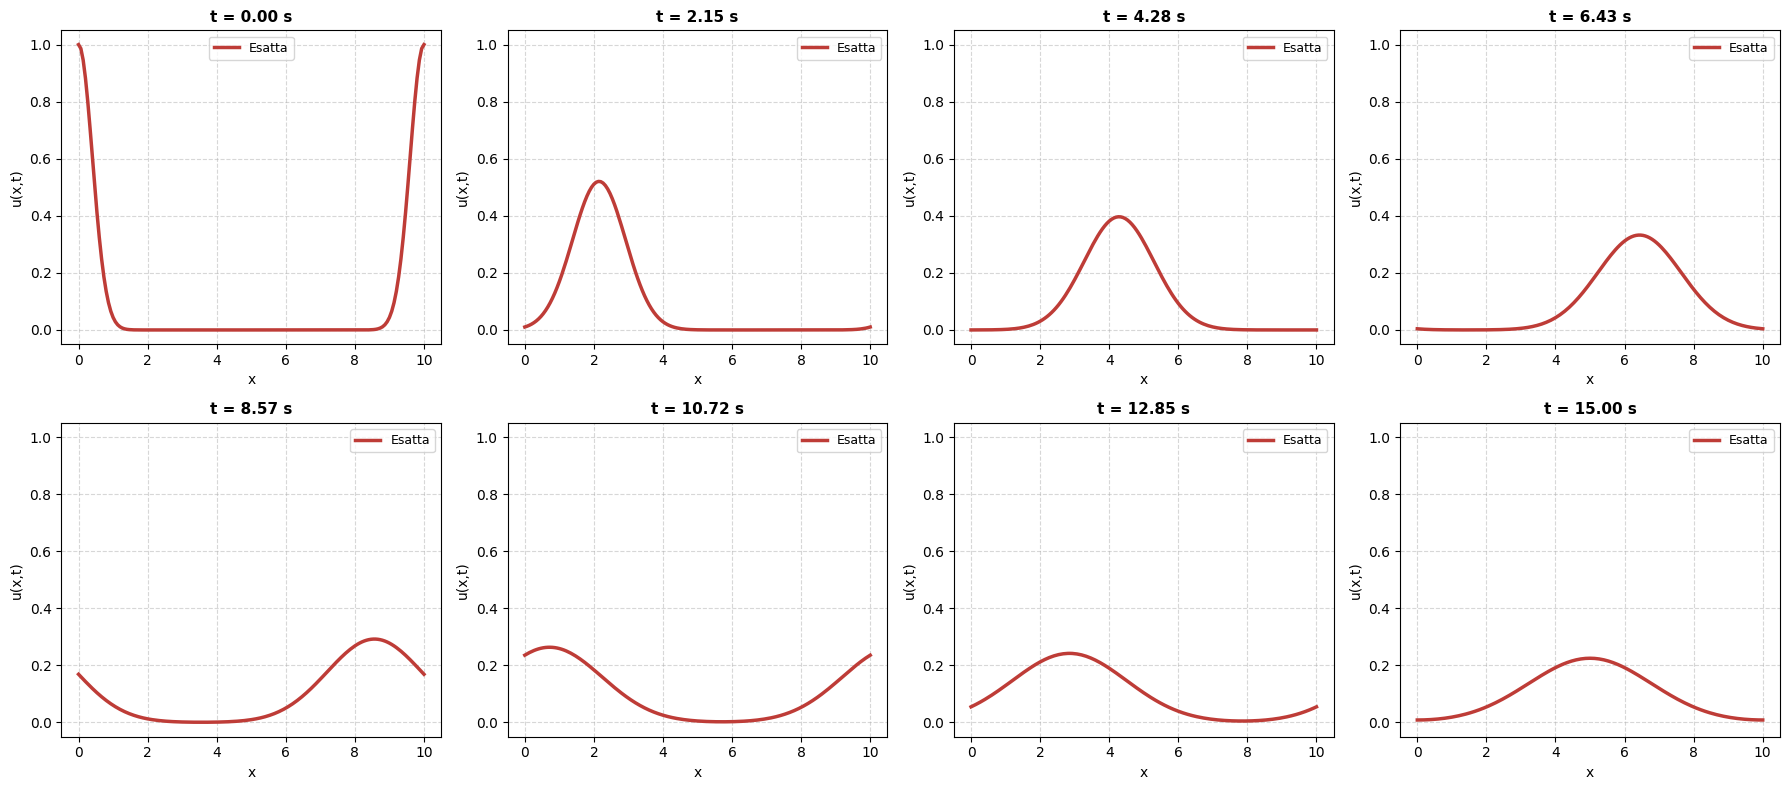

In [6]:
# Chiama la funzione per risolvere numericamente il problema con condizioni al contorno periodiche
x_num, t_num, sol_num, dt_num, M_num = solve_problem(
    problem_type="periodic", # Specifica la tipologia di problema (periodico)
    L=L,                     # Lunghezza del dominio spaziale
    N=N,                     # Numero di intervalli della griglia spaziale
    mu=mu,                   # Coefficiente di diffusione (o parametro fisico del problema)
    T_final=T_final,         # Tempo finale della simulazione
    safety=safety,           # Fattore di sicurezza per la stabilità del metodo (es. CFL)
    sigma=0.4                # Parametro per definire la larghezza della condizione iniziale
)

# Genera 8 istanti di tempo equispaziati tra 0 e T_final per i quali visualizzare i grafici
time_values = np.linspace(0, T_final, 8)

# Crea una figura con una griglia di sottogrefici (2 righe e 4 colonne) di dimensioni 18x8 pollici
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
# Appiattisce la matrice dei sotto-grafici (2x4) in un array monodimensionale da 8 elementi per iterare più facilmente
axes = axes.ravel()

# Cicla attraverso gli 8 istanti di tempo selezionati
for idx, time in enumerate(time_values):
    # Seleziona l'asse (il sotto-grafico) corrispondente all'indice corrente
    ax = axes[idx]

    # Trova l'indice temporale nella simulazione numerica più vicino al tempo 'time' desiderato
    n_time = np.argmin(np.abs(t_num - time))

    # Estrae la soluzione numerica nello spazio corrispondente all'istante di tempo calcolato
    u_num = sol_num[n_time, :]

    # Calcola la soluzione analitica esatta per le coordinate spaziali e l'istante di tempo corrente
    u_exact = exact_periodic_solution(
        x_num,
        t_num[n_time],
        L=L,
        mu=mu,
        sigma=0.4,
        K=100, # Numero di termini per l'approssimazione della serie della soluzione esatta
    )

    # Esatta: Linea continua skyblue
    # Disegna la soluzione esatta come una linea continua azzurra
    ax.plot(x_num, u_exact, color="#BE3C37", linewidth=2.5, label="Esatta")

    # Numerica: Linea a trattini e marker rossi (#BE3C37)
    # Disegna la soluzione numerica con una linea tratteggiata rossa, markers circolari ogni 10 punti spaziali
    #ax.plot(
     #   x_num,
     #   u_num,
    #    "--",
     #   color="skyblue",
     #   marker="o",
     #   markersize=3,
     #   markevery=10,
      #  label="Numerica"
   # )

    # Imposta il titolo del sotto-grafico mostrando il tempo effettivo formattato a due cifre decimali
    ax.set_title(f"t = {t_num[n_time]:.2f} s", fontsize=11, fontweight='bold')
    # Imposta l'etichetta dell'asse delle ascisse
    ax.set_xlabel("x")
    # Imposta l'etichetta dell'asse delle ordinate
    ax.set_ylabel("u(x,t)")

    # Fisso l'asse y leggermente allargato per non tagliare i marker sui bordi
    # Imposta i limiti verticali del grafico per garantire visibilità ottimale
    ax.set_ylim(-0.05, 1.05)

    # Attiva la griglia di sfondo sul sotto-grafico con linea tratteggiata e opacità al 50%
    ax.grid(True, linestyle="--", alpha=0.5)
    # Mostra la legenda nel sotto-grafico corrente con dimensione del font a 9
    ax.legend(fontsize=9)

# Stampa un messaggio di conferma nella console
print("CASO PERIODICO - CONFRONTO ESATTA / NUMERICA AL VARIARE DI t")
# Ottimizza la spaziatura tra i vari sotto-grafici per evitare sovrapposizioni di testi ed etichette
plt.tight_layout()
# Visualizza a schermo l'intera figura con gli 8 grafici generati
plt.show()

# ============================================================
# 6.1 GIF 1: CASO PERIODICO - SOLO SOLUZIONE ESATTA
# ============================================================


CASO PERIODICO - SOLO SOLUZIONE ESATTA


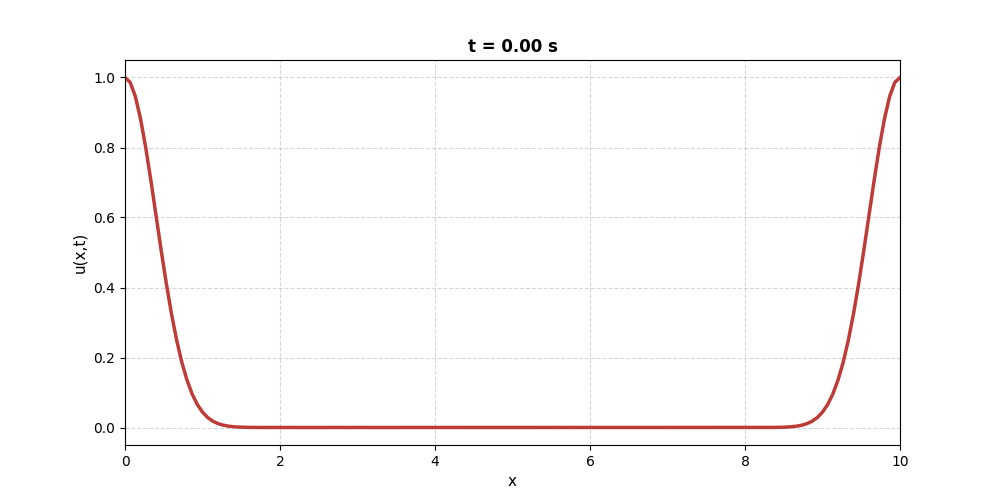

In [7]:
# Per non avere una GIF troppo pesante, campiono alcuni frame
# Definisce il numero totale di frame desiderati per l'animazione (80 frame)
num_frames = 80
# Genera gli indici temporali campionando 80 punti equispaziati tra 0 e il numero massimo di step M_num, convertiti in interi
frame_indices = np.linspace(0, M_num, num_frames, dtype=int)

# Crea una nuova figura e un asse per il grafico con dimensioni 10x5 pollici
fig, ax = plt.subplots(figsize=(10, 5))

# Inizializzazione linea con la nuova palette di colori
# Esatta: Rosso Vivo
# Inizializza l'oggetto grafico per la soluzione esatta (linea continua rossa, spessore 2.5)
line_exact, = ax.plot([], [], color="#BE3C37", linestyle="-", linewidth=2.5, label="Esatta")

# Inizializza l'oggetto per il titolo del grafico con font in grassetto e dimensione 12
title = ax.set_title("", fontsize=12, fontweight='bold')

# Imposta l'etichetta dell'asse x con dimensione del font a 11
ax.set_xlabel("x", fontsize=11)
# Imposta l'etichetta dell'asse y con dimensione del font a 11
ax.set_ylabel("u(x,t)", fontsize=11)
# Imposta i limiti dell'asse x da 0 alla lunghezza del dominio L
ax.set_xlim(0, L)
# Asse y leggermente allargato per non tagliare i punti estremi a 0 e 1
# Imposta i limiti dell'asse y per ottimizzare la visualizzazione
ax.set_ylim(-0.05, 1.05)
# Attiva la griglia di sfondo con linea tratteggiata e opacità ridotta al 50%
ax.grid(True, linestyle="--", alpha=0.5)

# Definisce la funzione di inizializzazione per l'animazione (svuota i dati della linea e del titolo)
def init():
    line_exact.set_data([], []) # Svuota i dati della linea esatta
    title.set_text("")          # Cancella il testo del titolo
    return line_exact, title    # Ritorna gli elementi grafici da aggiornare

# Definisce la funzione di aggiornamento chiamata per ogni frame dell'animazione
def update(frame_id):
    # Recupera l'indice temporale effettivo della simulazione corrispondente al frame corrente
    n = frame_indices[frame_id]
    # Estrae il valore del tempo corrente in secondi
    current_time = t_num[n]

    # Calcola la soluzione analitica esatta per le coordinate spaziali all'istante di tempo corrente
    u_exact = exact_periodic_solution(
        x_num,
        current_time,
        L=L,
        mu=mu,
        sigma=0.4,
        K=100,
    )

    # Aggiorna i dati della linea della soluzione esatta con i nuovi valori spaziali e analitici
    line_exact.set_data(x_num, u_exact)
    # Aggiorna il titolo del grafico mostrando il tempo corrente formattato a due cifre decimali
    title.set_text(f"t = {current_time:.2f} s")

    # Ritorna gli elementi modificati per consentire l'ottimizzazione del disegno (blitting)
    return line_exact, title

# Crea l'oggetto animazione accoppiando la figura, la funzione di update, i frame totali e i millisecondi di intervallo
anim = FuncAnimation(
    fig,
    update,
    frames=len(frame_indices),
    init_func=init,
    blit=True,     # Ottimizza il rendering aggiornando solo le parti del grafico che cambiano davvero
    interval=120   # millisecondi tra i frame
)

# Salvataggio GIF
# Definisce il nome del file di output per la GIF
gif_name = "periodic_exact_only.gif"
# Salva l'animazione su disco in formato GIF utilizzando il motore PillowWriter impostando 10 frame per secondo
anim.save(gif_name, writer=PillowWriter(fps=10))

# Chiude la figura per evitare che Matplotlib la mostri come immagine statica nel notebook
plt.close(fig)

# Stampa un messaggio di conferma nella console
print("CASO PERIODICO - SOLO SOLUZIONE ESATTA")
# Mostra la GIF in Colab / notebook
# Carica e visualizza a schermo il file GIF appena salvato nel notebook
display(Image(filename=gif_name))

# ========================================================
# 6.2 GIF 1: CASO PERIODICO - CONFRONTO ESATTA / NUMERICA
# ========================================================


CASO PERIODICO - CONFRONTO ESATTA / NUMERICA


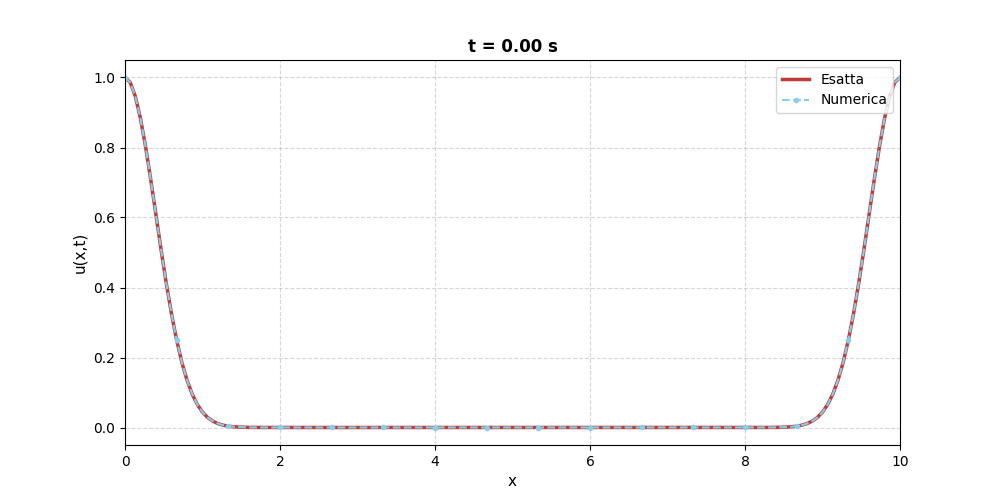

In [8]:
# Per non avere una GIF troppo pesante, campiono alcuni frame
# Definisce il numero totale di frame desiderati per l'animazione (80 frame)
num_frames = 80
# Genera gli indici temporali campionando 80 punti equispaziati tra 0 e il numero massimo di step M_num, convertiti in interi
frame_indices = np.linspace(0, M_num, num_frames, dtype=int)

# Crea una nuova figura e un asse per il grafico con dimensioni 10x5 pollici
fig, ax = plt.subplots(figsize=(10, 5))

# Inizializzazione linee con la nuova palette di colori
# Esatta: Grigio Antracite scuro | Numerica: Rosso Vivo
# Inizializza l'oggetto grafico per la soluzione esatta (linea continua rossa, spessore 2.5)
line_exact, = ax.plot([], [], color="#BE3C37", linestyle="-", linewidth=2.5, label="Esatta")
# Inizializza l'oggetto grafico per la soluzione numerica (linea tratteggiata azzurra con marker circolari ogni 10 punti)
line_num,   = ax.plot([], [], color="skyblue", linestyle="--", marker="o", markersize=3, markevery=10, label="Numerica")

# Inizializza l'oggetto per il titolo del grafico con font in grassetto e dimensione 12
title = ax.set_title("", fontsize=12, fontweight='bold')

# Imposta l'etichetta dell'asse x con dimensione del font a 11
ax.set_xlabel("x", fontsize=11)
# Imposta l'etichetta dell'asse y con dimensione del font a 11
ax.set_ylabel("u(x,t)", fontsize=11)
# Imposta i limiti dell'asse x da 0 alla lunghezza del dominio L
ax.set_xlim(0, L)
# Asse y leggermente allargato per non tagliare i marker a 0 e 1
# Imposta i limiti dell'asse y per ottimizzare la visualizzazione ed evitare tagli dei punti estremi
ax.set_ylim(-0.05, 1.05)
# Attiva la griglia di sfondo con linea tratteggiata e opacità ridotta al 50%
ax.grid(True, linestyle="--", alpha=0.5)
# Mostra la legenda posizionandola nell'angolo in alto a destra con dimensione del font a 10
ax.legend(fontsize=10, loc="upper right")

# Definisce la funzione di inizializzazione per l'animazione (svuota i dati di linee e titolo)
def init():
    line_exact.set_data([], []) # Svuota i dati della linea esatta
    line_num.set_data([], [])   # Svuota i dati della linea numerica
    title.set_text("")          # Cancella il testo del titolo
    return line_exact, line_num, title # Ritorna gli elementi grafici da aggiornare

# Definisce la funzione di aggiornamento chiamata per ogni frame dell'animazione
def update(frame_id):
    # Recupera l'indice temporale effettivo della simulazione corrispondente al frame corrente
    n = frame_indices[frame_id]
    # Estrae il valore del tempo corrente in secondi
    current_time = t_num[n]

    # Estrae il vettore della soluzione numerica all'istante n
    u_num = sol_num[n, :]
    # Calcola la soluzione analitica esatta per le coordinate spaziali all'istante di tempo corrente
    u_exact = exact_periodic_solution(
        x_num,
        current_time,
        L=L,
        mu=mu,
        sigma=0.4,
        K=100,
    )

    # Aggiorna i dati della linea della soluzione esatta con i nuovi valori spaziali e analitici
    line_exact.set_data(x_num, u_exact)
    # Aggiorna i dati della linea della soluzione numerica con i nuovi valori spaziali e numerici
    line_num.set_data(x_num, u_num)
    # Aggiorna il titolo del grafico mostrando il tempo corrente formattato a due cifre decimali
    title.set_text(f"t = {current_time:.2f} s")

    # Ritorna gli elementi modificati per consentire l'ottimizzazione del disegno (blitting)
    return line_exact, line_num, title

# Crea l'oggetto animazione accoppiando la figura, la funzione di update, i frame totali e i millisecondi di intervallo
anim = FuncAnimation(
    fig,
    update,
    frames=len(frame_indices),
    init_func=init,
    blit=True,     # Ottimizza il rendering aggiornando solo le parti del grafico che cambiano davvero
    interval=120   # millisecondi tra i frame
)

# Salvataggio GIF
# Definisce il nome del file di output per la GIF
gif_name = "periodic_exact_vs_numeric.gif"
# Salva l'animazione su disco in formato GIF utilizzando il motore PillowWriter impostando 10 frame per secondo
anim.save(gif_name, writer=PillowWriter(fps=10))

# Chiude la figura per evitare che Matplotlib la mostri come immagine statica nel notebook
plt.close(fig)

# Stampa un messaggio di conferma nella console
print("CASO PERIODICO - CONFRONTO ESATTA / NUMERICA")
# Mostra la GIF in Colab / notebook
# Carica e visualizza a schermo il file GIF appena salvato nel notebook
display(Image(filename=gif_name))

# ============================================================
# 7. PLOT 2: CASO PERIODICO - RAFFINAMENTO DELLE MESH
# ============================================================


CASO PERIODICO - RAFFINAMENTO DELLE MESH


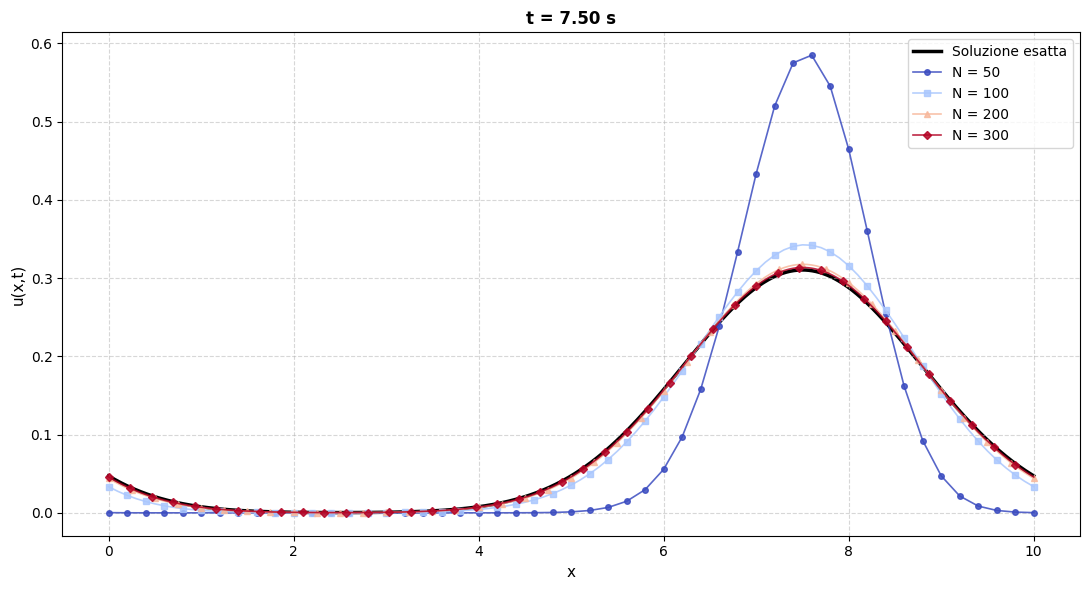

In [9]:
T_mesh = T_final / 2       # scelgo un tempo centrale
# Array contenente i diversi numeri di intervalli spaziali (nodi) per testare la convergenza numerica
mesh_values = [50, 100, 200, 300]

# Inizializza una nuova figura Matplotlib con dimensioni di 11x6 pollici
plt.figure(figsize=(11, 6))

# Soluzione esatta su griglia fine, usata come riferimento visivo (nera e spessa)
# Genera una griglia spaziale di riferimento molto fitta con 1000 punti per una rappresentazione fluida della soluzione esatta
x_ref = np.linspace(0, L, 1000)
# Calcola la soluzione analitica esatta al tempo centrale T_mesh sulla griglia fine di riferimento
u_ref = exact_periodic_solution(
    x_ref,
    T_mesh,
    L=L,
    mu=mu,
    sigma=0.4,
    K=100,
)

# Grafica la soluzione esatta di riferimento
plt.plot(
    x_ref,
    u_ref,
    color="black",
    linewidth=2.5,
    linestyle="-",
    label="Soluzione esatta",
    zorder=1 # Mantiene la linea di riferimento sullo sfondo rispetto ai nodi numerici
)

# Generiamo una mappa di colori ad alto contrasto (es. 'coolwarm', 'plasma', o 'jet')
# Questo distribuisce i colori in modo uniforme tra le 4 mesh
# Estrae 4 colori campionati uniformemente dalla colormap 'coolwarm' (dal blu al rosso passando per il bianco)
colori_mesh = plt.cm.coolwarm(np.linspace(0, 1, len(mesh_values)))
marcatori = ['o', 's', '^', 'D'] # Forme diverse per distinguere i nodi anche in bianco e nero

# Cicla attraverso i diversi valori di discretizzazione spaziale (N_mesh) definiti in mesh_values
for idx, N_mesh in enumerate(mesh_values):
    # Risolve numericamente il problema fino al tempo T_mesh usando il valore corrente di N_mesh
    x_num, t_num, sol_num, dt_num, M_num = solve_problem(
        problem_type="periodic",
        L=L,
        N=N_mesh,
        mu=mu,
        T_final=T_mesh, # La simulazione si ferma direttamente al tempo d'interesse
        safety=0.8,
        sigma=0.4
    )

    # Grafica la soluzione numerica finale (all'ultimo step temporale, che corrisponde a T_mesh)
    plt.plot(
        x_num,
        sol_num[-1, :],                 # Prende l'ultimo indice temporale della matrice delle soluzioni
        color=colori_mesh[idx],         # Assegna il colore estratto dalla colormap per l'indice corrente
        marker=marcatori[idx],          # Assegna il marcatore geometrico corrispondente
        markersize=4,                   # Imposta la dimensione dei marker a 4 punti
        markevery=max(1, N_mesh // 40), # Evita di affollare il grafico di marker nelle mesh fitte
        linewidth=1.2,                  # Imposta lo spessore della linea numerica a 1.2
        alpha=0.85,                     # Trasparenza per vedere le sovrapposizioni
        label=f"N = {N_mesh}"           # Stringa per la legenda che identifica il numero di nodi della mesh
    )

# Stampa un messaggio informativo di avanzamento nella console
print("CASO PERIODICO - RAFFINAMENTO DELLE MESH")
# Imposta l'etichetta dell'asse x con dimensione del font a 11
plt.xlabel("x", fontsize=11)
# Imposta l'etichetta dell'asse y con dimensione del font a 11
plt.ylabel("u(x,t)", fontsize=11)
# Imposta il titolo del grafico principale mostrando il tempo bloccato, in grassetto e font 12
plt.title(f"t = {T_mesh:.2f} s", fontsize=12, fontweight='bold')
# Attiva la griglia con stile tratteggiato e opacità al 50%
plt.grid(True, linestyle="--", alpha=0.5)
# Mostra la legenda nell'angolo in alto a destra con dimensione del font a 10
plt.legend(fontsize=10, loc="upper right")
# Ottimizza automaticamente i margini della figura per evitare ritagli del testo
plt.tight_layout()
# Visualizza il grafico finale a schermo
plt.show()

# ============================================================
# 10. PLOT 3: ANALISI DELL'ORDINE DI ACCURATEZZA SPAZIALE
# ============================================================


ANALISI DELL'ORDINE DI ACCURATEZZA
Ordine di convergenza spaziale stimato: 2.36


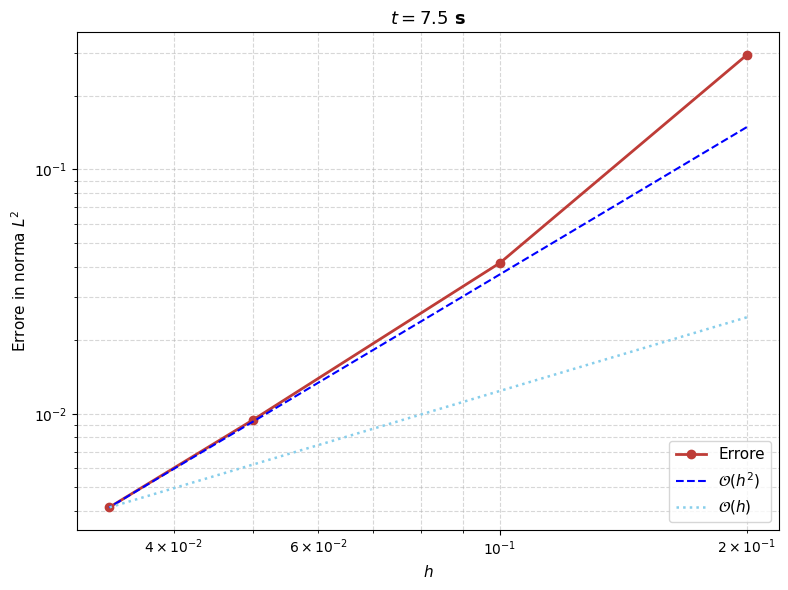

In [10]:
# Scegliamo un tempo finale fisso per l'analisi dell'errore
T_analysis = 7.5

# Definiamo un vettore con diversi valori di N (raffinamento della mesh)
N_values = np.array([50, 100, 200, 300])
errors = [] # Lista vuota in cui accumulare l'errore L2 calcolato per ciascuna griglia
h_values = [] # Lista vuota in cui accumulare i corrispondenti passi spaziali h

for N_mesh in N_values:
    # Calcolo del passo spaziale h
    h = L / N_mesh
    h_values.append(h) # Salva il valore del passo spaziale corrente nella lista h_values

    # Risoluzione numerica con il valore corrente di N
    x_num, t_num, sol_num, dt_num, M_num = solve_problem(
        problem_type="periodic",
        L=L,
        N=N_mesh,
        mu=mu,
        T_final=T_analysis,
        safety=safety,
        sigma=0.4
    )

    # Soluzione numerica finale (all'ultimo passo temporale)
    u_numeric_final = sol_num[-1, :]

    # Soluzione esatta calcolata sugli stessi identici nodi della griglia numerica
    u_exact_final = exact_periodic_solution(
        x_num,
        T_analysis,
        L=L,
        mu=mu,
        sigma=0.4,
        K=150  # Aumentiamo K per garantire massima precisione della serie
    )

    # Calcolo dell'errore in norma L2 discreta
    err_L2 = np.sqrt(h * np.sum((u_numeric_final[:-1] - u_exact_final[:-1])**2))
    errors.append(err_L2) # Salva l'errore L2 calcolato nella lista errors

# Conversione in array numpy per i calcoli logaritmici
h_values = np.array(h_values)
errors = np.array(errors)

# Calcolo della pendenza stimata (ordine numerico di convergenza) tramite regressione lineare
pendenza, _ = np.polyfit(np.log(h_values), np.log(errors), 1)

# --- Grafico log-log dell'errore ---
plt.figure(figsize=(8, 6))

# Curva dell'errore effettivo
plt.loglog(h_values, errors, marker='o', color='#BE3C37', linewidth=2, label=f'Errore')

# Retta di riferimento teorica O(h^2) - Secondo Ordine
costante_allineamento_2 = errors[-1] / (h_values[-1]**2)
plt.loglog(h_values, costante_allineamento_2 * (h_values**2), '--', color='blue', label=r'$\mathcal{O}(h^2)$')

# Retta di riferimento teorica O(h) - Primo Ordine (Aggiunta)
# Allineata anch'essa all'ultimo punto dell'errore per un confronto visivo immediato
costante_allineamento_1 = errors[-1] / (h_values[-1]**1)
plt.loglog(h_values, costante_allineamento_1 * (h_values**1), ':', color='skyblue', linewidth=1.8, label=r'$\mathcal{O}(h)$')

# Stampa un messaggio descrittivo nella console di Python
print("ANALISI DELL'ORDINE DI ACCURATEZZA")
print(f"Ordine di convergenza spaziale stimato: {pendenza:.2f}")

# Impostazioni etichette e stile grafico
plt.xlabel('$h$', fontsize=11)
plt.ylabel('Errore in norma $L^2$', fontsize=11)
plt.title(f'$t = {T_analysis}$ s', fontsize=13, fontweight='bold')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=11, loc="lower right") # Spostata in basso a destra per non coprire le rette
plt.tight_layout()
plt.show()

# ============================================================
# 11. PLOT 4: ANALISI DELL'ORDINE DI ACCURATEZZA TEMPORALE
# ============================================================


ANALISI DELL'ORDINE DI ACCURATEZZA TEMPORALE
Ordine di convergenza stimato nel tempo: 0.93


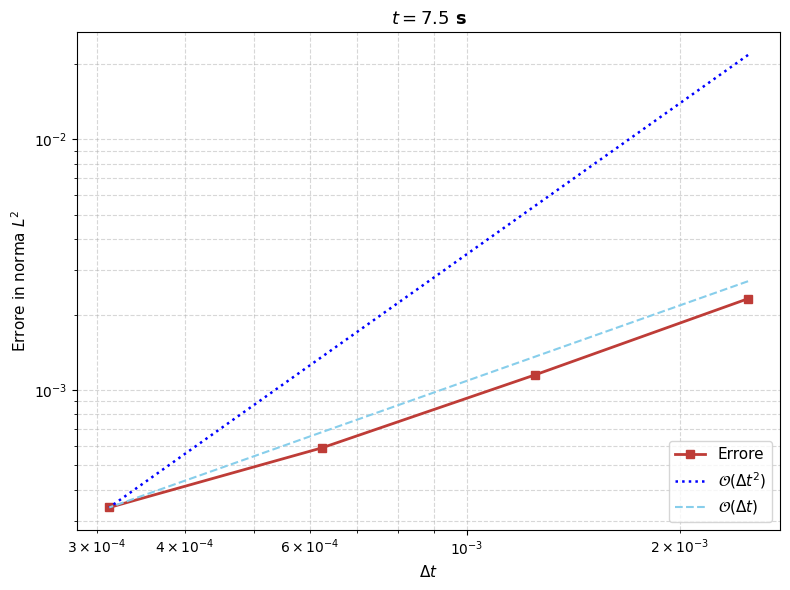

In [11]:
# Scegliamo un tempo finale fisso per l'analisi dell'errore
T_analysis = 7.5

# Fissiamo N molto grande per minimizzare l'errore spaziale (errore di mesh)
# In questo modo l'errore dominante sarà solo quello legato al passo temporale dt
N_fixed = 400
h_fixed = L / N_fixed

# Definiamo un vettore con diversi fattori di sicurezza (safety factor) per variare dt
safety_values = np.array([0.8, 0.4, 0.2, 0.1])

dt_values = [] # Lista vuota in cui accumulare i passi temporali dt
errors_time = [] # Lista vuota in cui accumulare l'errore L2 per ciascun dt

for s_val in safety_values:
    # Risoluzione numerica con il valore corrente di safety (e quindi di dt)
    x_num, t_num, sol_num, dt_num, M_num = solve_problem(
        problem_type="periodic",
        L=L,
        N=N_fixed,
        mu=mu,
        T_final=T_analysis,
        safety=s_val,
        sigma=0.4
    )

    dt_values.append(dt_num) # Salva il valore del passo temporale corrente

    # Soluzione numerica finale (all'ultimo passo temporale)
    u_numeric_final = sol_num[-1, :]

    # Soluzione esatta calcolata sugli stessi nodi spaziali al tempo T_analysis
    u_exact_final = exact_periodic_solution(
        x_num,
        T_analysis,
        L=L,
        mu=mu,
        sigma=0.4,
        K=150  # Massimo numero di termini per garantire la precisione della serie
    )

    # Calcolo dell'errore in norma L2 discreta
    err_L2 = np.sqrt(h_fixed * np.sum((u_numeric_final[:-1] - u_exact_final[:-1])**2))
    errors_time.append(err_L2)

# Conversione in array numpy per i calcoli logaritmici
dt_values = np.array(dt_values)
errors_time = np.array(errors_time)

# Calcolo della pendenza stimata (ordine numerico di convergenza temporale)
pendenza_tempo, _ = np.polyfit(np.log(dt_values), np.log(errors_time), 1)

# --- Grafico log-log dell'errore temporale ---
plt.figure(figsize=(8, 6))

# Curva dell'errore effettivo rispetto a dt
plt.loglog(dt_values, errors_time, marker='s', color='#BE3C37', linewidth=2,
           label=f'Errore')


costante_allineamento_2 = errors_time[-1] / (dt_values[-1]**2)
plt.loglog(dt_values, costante_allineamento_2 * (dt_values**2), ':', color='blue', linewidth=1.8, label=r'$\mathcal{O}(\Delta t^2)$')
# Retta di riferimento teorica O(dt) - Primo Ordine
costante_allineamento_1 = errors_time[-1] / (dt_values[-1]**1)
plt.loglog(dt_values, costante_allineamento_1 * (dt_values**1), '--', color='skyblue', label=r'$\mathcal{O}(\Delta t)$')

# Retta di riferimento teorica O(dt^2) - Secondo Ordine (Aggiunta)
# Anch'essa allineata visivamente ai dati reali per il confronto delle pendenze



print("ANALISI DELL'ORDINE DI ACCURATEZZA TEMPORALE")
print(f"Ordine di convergenza stimato nel tempo: {pendenza_tempo:.2f}")

# Configurazione etichette e stile grafico
plt.xlabel(r'$\Delta t$', fontsize=11)
plt.ylabel('Errore in norma $L^2$', fontsize=11)
plt.title(f'$t = {T_analysis}$ s', fontsize=13, fontweight='bold')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=11, loc="lower right") # Spostata in basso a destra
plt.tight_layout()
plt.show()

# ============================================================
# 12. PLOT: EFFETTO DEL PASSO TEMPORALE dt stabile vs dt appena instabile
# ============================================================


h                    = 0.066667
dt critico            = 0.022222
dt stabile      = 0.017778
dt appena instabile    = 0.023556
ANALISI DELLA STABILITÀ AL VARIARE DELLA MESH TEMPORALE


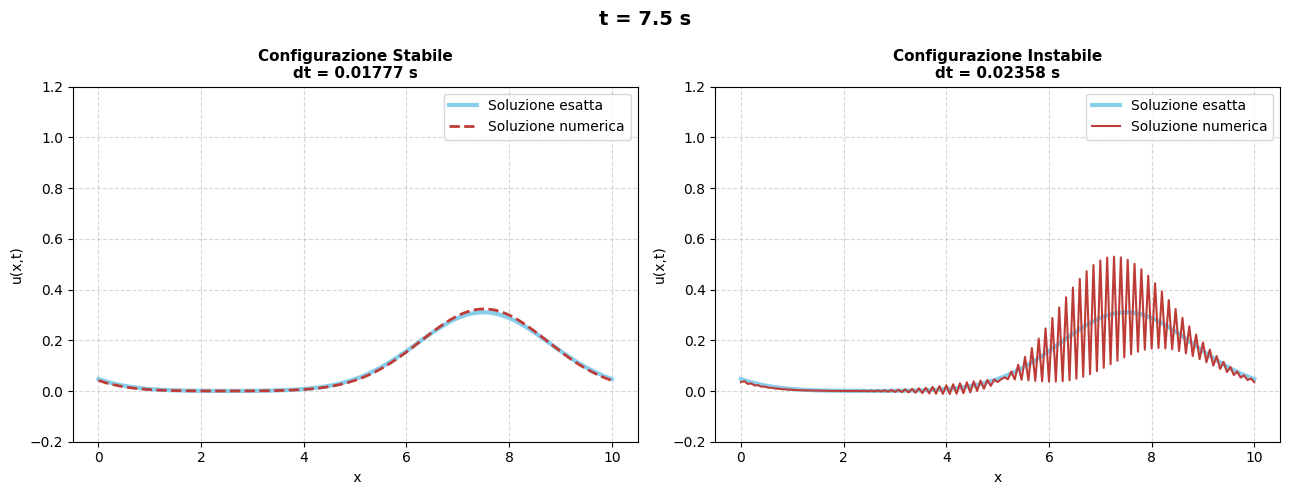

In [12]:
T_plot = 7.5
sigma = 0.4

# Uso lo stesso h del codice principale
# Calcola il passo di discretizzazione spaziale dividendo la lunghezza per il numero di intervalli
h = L / N

# Passo temporale critico dato dalla condizione di stabilità
# Calcola il vincolo teorico superiore per dt (condizione CFL) per garantire la convergenza del metodo esplicito
dt_critico = min(2 * mu, h**2 / (2 * mu))

# Scelgo un dt stabile e uno appena instabile
# Sceglie un passo temporale inferiore del 20% rispetto al limite critico (sicuro)
dt_stabile = 0.8 * dt_critico
# Sceglie un passo temporale superiore del 6% rispetto al limite critico (provoca instabilità numerica)
dt_instabile = 1.06 * dt_critico

# Stampe informative dei parametri temporali e spaziali calcolati sulla console
print(f"h                    = {h:.6f}")
print(f"dt critico            = {dt_critico:.6f}")
print(f"dt stabile      = {dt_stabile:.6f}")
print(f"dt appena instabile    = {dt_instabile:.6f}")
print("ANALISI DELLA STABILITÀ AL VARIARE DELLA MESH TEMPORALE")


def solve_periodic_with_fixed_dt(L, N, mu, T_final, dt, sigma):
    """
    Risolve il caso periodico usando un dt fissato manualmente.

    Questa funzione serve per confrontare cosa succede
    quando dt rispetta o supera appena la condizione di stabilità.
    """

    # Ricalcola il passo spaziale h all'interno dello scope della funzione
    h = L / N

    # Griglia periodica: non conto due volte x=0 e x=L
    # Genera la coordinata spaziale escludendo l'estremo destro per via della natura ciclica delle condizioni
    x = np.linspace(0, L, N, endpoint=False)

    # Coefficienti dello schema centrato
    # Calcola i pesi della matrice di discretizzazione legati alla derivata seconda (diffusione) e prima (trasporto)
    alpha = mu / h**2 + 1 / (2 * h)
    beta  = -2 * mu / h**2
    gamma = mu / h**2 - 1 / (2 * h)

    # Matrice periodica
    # Assembla la matrice dei coefficienti del sistema lineare includendo i raccordi periodici sui bordi
    A = build_periodic_matrix(N, alpha, beta, gamma)
    b = np.zeros(N) # Vettore dei termini noti nullo

    # Condizione iniziale
    # Genera il profilo a campana gaussiana iniziale adattato alle condizioni al contorno periodiche
    U = periodic_gaussian(x, L, sigma=sigma)

    # Numero di passi temporali
    # Calcola quanti cicli temporali servono per approssimare T_final con il dt scelto, arrotondando all'intero
    M = int(np.round(T_final / dt))

    # Correggo leggermente dt per arrivare esattamente a T_final
    # Ricalcola il passo temporale esatto per fare in modo che dopo M passi si tocchi precisamente T_final
    dt_effettivo = T_final / M

    # Ciclo temporale esplicito (schema di Eulero in avanti)
    for n in range(M):
        U = U + dt_effettivo * (A @ U + b)

    # Aggiungo il punto x=L solo per visualizzare la periodicità
    # Crea una nuova griglia spaziale estesa che include anche l'ultimo estremo destro
    x_full = np.linspace(0, L, N + 1)
    U_full = np.zeros(N + 1) # Alloca il vettore della soluzione estesa

    # Copia i dati calcolati nel vettore esteso
    U_full[:-1] = U
    # Imposta il valore nel nodo x=L uguale al valore nel nodo x=0 per continuità periodica nel plot
    U_full[-1] = U[0]

    # Ritorna la griglia completa, i valori della soluzione, il dt reale utilizzato e il numero totale di passi eseguiti
    return x_full, U_full, dt_effettivo, M


# ============================================================
# Risolvo con dt stabile
# ============================================================

# Esegue l'algoritmo impostando il passo temporale sotto la soglia critica
x_stabile, u_stabile, dt_stabile_eff, M_stabile = solve_periodic_with_fixed_dt(
    L=L,
    N=N,
    mu=mu,
    T_final=T_plot,
    dt=dt_stabile,
    sigma=sigma
)


# ============================================================
# Risolvo con dt appena instabile
# ============================================================

# Esegue l'algoritmo impostando il passo temporale sopra la soglia critica per innescare l'esplosione numerica
x_instabile, u_instabile, dt_instabile_eff, M_instabile = solve_periodic_with_fixed_dt(
    L=L,
    N=N,
    mu=mu,
    T_final=T_plot,
    dt=dt_instabile,
    sigma=sigma
)


# ============================================================
# Soluzione esatta di riferimento
# ============================================================

# Griglia spaziale fitta e indipendente per rappresentare accuratamente la funzione analitica continua
x_ref = np.linspace(0, L, 1000)

# Calcola analiticamente la soluzione esatta al tempo T_plot come termine di confronto qualitativo
u_exact = exact_periodic_solution(
    x_ref,
    T_plot,
    L=L,
    mu=mu,
    sigma=sigma,
    K=100,
)


# ============================================================
# Grafico
# ============================================================

# Crea una nuova figura Matplotlib con layout orizzontale a due riquadri, di dimensione 13x5 pollici
plt.figure(figsize=(13, 5))


# ----------------------------
# Caso stabile
# ----------------------------

# Seleziona e configura il primo sotto-grafico (riquadro di sinistra)
plt.subplot(1, 2, 1)

# Esatta: skyblue
# Disegna la linea di riferimento analitica continua di colore azzurro e spessore 3
plt.plot(
    x_ref,
    u_exact,
    color="skyblue",
    linewidth=3,
    label="Soluzione esatta"
)

# Disegna la curva numerica stabile come linea tratteggiata rossa
plt.plot(
    x_stabile,
    u_stabile,
    color="#BE3C37",
    linewidth=2,
    linestyle="--",
    label="Soluzione numerica"
)

# Imposta il titolo del sotto-grafico di sinistra evidenziando il dt effettivo in grassetto
plt.title(
    f"Configurazione Stabile\n"
    f"dt = {dt_stabile_eff:.5f} s",
    fontsize=11, fontweight='bold'
)

# Configura gli assi, i limiti verticali, la griglia e la legenda del primo riquadro
plt.xlabel(" x")
plt.ylabel("u(x,t)")
plt.ylim(-0.2, 1.2)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(fontsize=10)


# ----------------------------
# Caso appena instabile
# ----------------------------

# Seleziona e configura il secondo sotto-grafico (riquadro di destra)
plt.subplot(1, 2, 2)

# Esatta: skyblue
# Disegna la linea analitica esatta anche sul secondo riquadro come riferimento per mostrare lo scostamento
plt.plot(
    x_ref,
    u_exact,
    color="skyblue",
    linewidth=3,
    label="Soluzione esatta"
)

# Disegna la soluzione numerica instabile che mostrerà le oscillazioni parassite distruttive
plt.plot(
    x_instabile,
    u_instabile,
    color="#BE3C37",
    linewidth=1.5,
    label="Soluzione numerica"
)

# Imposta il titolo del sotto-grafico di destra evidenziando il dt fuori controllo in grassetto
plt.title(
    f"Configurazione Instabile\n"
    f"dt = {dt_instabile_eff:.5f} s",
    fontsize=11, fontweight='bold'
)

plt.xlabel("x")
plt.ylabel("u(x,t)")

# Se l'instabilità è forte a t=7.5s, i valori numerici potrebbero uscire dai limiti fisici [0,1].
# Manteniamo il limite bloccato per evidenziare il fallimento distruttivo dello schema.
# Blocca l'asse delle ordinate allo stesso range per rendere evidente l'effetto di accumulo delle oscillazioni spurie
plt.ylim(-0.2, 1.2)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(fontsize=10)


# Aggiunge un titolo generale sovrapposto centrato in alto che indica il tempo della sezione fotografata
plt.suptitle(
    f"t = {T_plot} s",
    fontsize=14, fontweight='bold', y=0.98
)

# Bilancia e ottimizza gli spazi tra i due grafici e i titoli per prevenire sovrapposizioni di testo
plt.tight_layout()
# Esegue il rendering finale a schermo dell'intera figura di confronto sulla stabilità
plt.show()

# ============================================================
# 13. PLOT: EVOLUZIONE CASO DIRICHLET-NEUMANN
# ============================================================


EVOLUZIONE DELLA SOLUZIONE CON CONDIZIONI DIRICHLET-NEUMANN


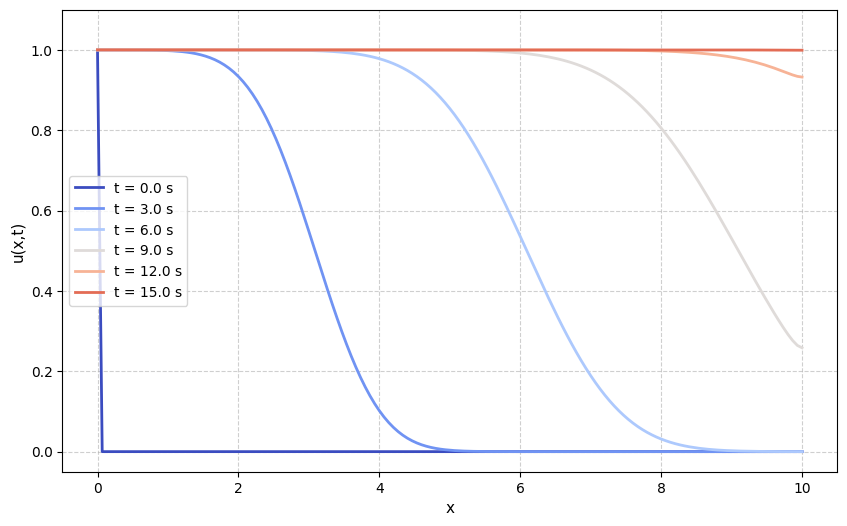

In [13]:
# Risolve numericamente il problema con condizioni al contorno di tipo misto (Dirichlet a un estremo, Neumann all'altro)
x_dn, t_dn, sol_dn, _, _ = solve_problem(
    problem_type="dirichlet_neumann", # Specifica la tipologia di vincoli al contorno
    L=L,                              # Lunghezza del dominio spaziale
    N=N,                              # Numero di intervalli della griglia spaziale
    mu=mu,                            # Coefficiente di diffusione del problema
    T_final=T_final,                  # Tempo finale della simulazione
    safety=safety,                    # Parametro di sicurezza per garantire la stabilità temporale
    sigma=0.4                         # Parametro di larghezza della condizione iniziale
)

# Selezioniamo 6 istanti temporali distribuiti per il grafico
# Genera 6 indici interi equispaziati estratti direttamente dall'intervallo dei passi temporali calcolati
istanti_plot = np.linspace(0, len(t_dn) - 1, 6, dtype=int)
# Genera una palette di 6 colori scalati lungo la colormap 'coolwarm' per differenziare i tempi (fino all'85% della mappa)
colors_dn = plt.cm.coolwarm(np.linspace(0, 0.85, len(istanti_plot)))

# Inizializza una nuova figura Matplotlib con dimensioni 10x6 pollici
plt.figure(figsize=(10, 6))

# Cicla attraverso gli indici temporali selezionati per tracciare le curve di soluzione
for idx, idx_t in enumerate(istanti_plot):
    # Grafica il profilo spaziale della soluzione u(x) corrispondente allo specifico istante temporale idx_t
    plt.plot(
        x_dn,
        sol_dn[idx_t, :],
        color=colors_dn[idx],       # Assegna il colore associato al passo temporale corrente
        linewidth=2,                # Imposta lo spessore della linea a 2 punti
        label=f"t = {t_dn[idx_t]:.1f} s" # Etichetta della legenda che mostra il tempo effettivo in secondi (con una cifra decimale)
    )

# Stampa un messaggio descrittivo nella console
print("EVOLUZIONE DELLA SOLUZIONE CON CONDIZIONI DIRICHLET-NEUMANN")
# Imposta l'etichetta dell'asse x (spazio) con dimensione del font a 11
plt.xlabel("x", fontsize=11)
# Imposta l'etichetta dell'asse y (valore della soluzione) con dimensione del font a 11
plt.ylabel("u(x,t)", fontsize=11)
# Fissa i limiti dell'asse y tra -0.05 e 1.1 per contenere visivamente l'evoluzione della soluzione senza tagli
plt.ylim(-0.05, 1.1)
# Attiva la griglia di sfondo con stile tratteggiato e opacità al 60%
plt.grid(True, linestyle="--", alpha=0.6)
# Crea e posiziona la legenda (questa prima chiamata viene sovrascritta da quella successiva)
plt.legend()
# Posiziona definitivamente la legenda sul lato sinistro-centrale del grafico, con dimensione del font a 10
plt.legend(loc="center left", fontsize=10)
# Mostra a schermo il grafico finale generato
plt.show()

# ============================================================
# 14. ANIMAZIONE GIF: EVOLUZIONE CASO DIRICHLET-NEUMANN
# ============================================================



In [14]:
# Risolve numericamente il problema con condizioni al contorno di tipo misto
x_dn, t_dn, sol_dn, _, _ = solve_problem(
    problem_type="dirichlet_neumann",
    L=L,
    N=N,
    mu=mu,
    T_final=T_final,
    safety=safety,
    sigma=0.4
)

# Per non avere una GIF troppo pesante, campiono alcuni frame (es. 80 frame)
num_frames = 80
frame_indices = np.linspace(0, len(t_dn) - 1, num_frames, dtype=int)

# Crea una nuova figura e un asse per il grafico con dimensioni 10x6 pollici
fig, ax = plt.subplots(figsize=(10, 6))

# Inizializzazione della linea che verrà aggiornata durante l'animazione
# Usiamo il colore iniziale della palette o un colore base, lo spessore a 2.5
line_dn, = ax.plot([], [], color="#BE3C37", linestyle="-", linewidth=2.5, label="Soluzione u(x,t)")

# Inizializza l'oggetto per il titolo dinamico del grafico
title = ax.set_title("", fontsize=12, fontweight='bold')

# Impostazione assi e griglia (identici al tuo plot statico)
ax.set_xlabel("x", fontsize=11)
ax.set_ylabel("u(x,t)", fontsize=11)
ax.set_xlim(0, L)
ax.set_ylim(-0.05, 1.1)
ax.grid(True, linestyle="--", alpha=0.6)

# Genera la stessa palette di colori 'coolwarm' scalata per il numero di frame totali
# In questo modo la linea cambierà colore dinamicamente mentre la simulazione avanza!
colors_dn = plt.cm.coolwarm(np.linspace(0, 0.85, num_frames))

# Definisce la funzione di inizializzazione per l'animazione
def init():
    line_dn.set_data([], [])
    title.set_text("")
    return line_dn, title

# Definisce la funzione di aggiornamento chiamata per ogni frame
def update(frame_id):
    # Recupera l'indice temporale effettivo
    n = frame_indices[frame_id]
    current_time = t_dn[n]

    # Estrae il vettore della soluzione all'istante n
    u_current = sol_dn[n, :]

    # Aggiorna i dati della linea e il suo colore dinamicamente
    line_dn.set_data(x_dn, u_current)
    line_dn.set_color(colors_dn[frame_id])

    # Aggiorna il titolo mostrando il tempo corrente
    title.set_text(f"t = {current_time:.2f} s")

    return line_dn, title

# Crea l'oggetto animazione
anim = FuncAnimation(
    fig,
    update,
    frames=num_frames,
    init_func=init,
    blit=True,     # Ottimizza il rendering aggiornando solo i pixel che cambiano
    interval=100   # Millisecondi tra un frame e l'altro
)

# Salvataggio della GIF su disco
gif_name = "dirichlet_neumann_evolution.gif"
anim.save(gif_name, writer=PillowWriter(fps=10))

# Chiude la figura per evitare che rimanga stampata l'immagine statica dell'ultimo frame
plt.close(fig)

print("ANIMAZIONE GENERATA CON SUCCESSO")
# Mostra la GIF all'interno del notebook/Colab
display(Image(filename=gif_name))

ANIMAZIONE GENERATA CON SUCCESSO
